# Phase 5 -- Evaluation & Comparison
## Project: Machine Learning-based Ransomware Detection
### Reference: Hirano & Kobayashi, IEEE CSR 2022

**What we cover:**
1. Reload models and data
2. Per-class performance analysis
3. ROC curves
4. Precision-Recall curves
5. Confusion matrices
6. Error analysis
7. Save model_results.parquet for app.py
8. Final comparison vs IEEE paper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.model_selection import GroupShuffleSplit

PROCESSED  = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\DATA\processed"
MODELS_DIR = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\MODELS"
RESULTS    = r"C:\Users\Shiva\Downloads\RANSMAP_PROJECT\RESULTS"
os.makedirs(RESULTS, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]     = 120
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


## 1. Reload Models and Data

In [2]:
df = pd.read_parquet(os.path.join(PROCESSED, "features_final.parquet"))

feat_cols = [c for c in df.columns
             if c not in ["trial_id", "window_start", "class_name",
                          "label", "is_malicious"]]

X = df[feat_cols].values
y = df["is_malicious"].values

scaler     = pickle.load(open(os.path.join(MODELS_DIR, "scaler.pkl"),     "rb"))
all_models = pickle.load(open(os.path.join(MODELS_DIR, "all_models.pkl"), "rb"))
X_scaled   = scaler.transform(X)

# Same trial-aware split as Phase 4
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["trial_id"]))

X_train,        X_test        = X[train_idx],        X[test_idx]
X_train_scaled, X_test_scaled = X_scaled[train_idx], X_scaled[test_idx]
y_train,        y_test        = y[train_idx],        y[test_idx]

print(f"Data loaded   : {df.shape}")
print(f"Models loaded : {list(all_models.keys())}")
print(f"Train size    : {len(X_train):,} windows")
print(f"Test size     : {len(X_test):,}  windows")
print(f"Test trials   : {df['trial_id'].iloc[test_idx].nunique()}")

Data loaded   : (137406, 33)
Models loaded : ['Random Forest', 'SVM', 'kNN', 'XGBoost']
Train size    : 109,066 windows
Test size     : 28,340  windows
Test trials   : 394


In [4]:
# Fit all models on this train split
print("Fitting models on trial-aware train split...")

all_models["Random Forest"].fit(X_train, y_train)
print("  Random Forest   fitted")

all_models["SVM"].fit(X_train_scaled, y_train)
print("  SVM             fitted")

all_models["kNN"].fit(X_train_scaled, y_train)
print("  kNN             fitted")

all_models["XGBoost"].fit(X_train, y_train)
print("  XGBoost         fitted")

# Model configs used throughout this notebook
model_configs = [
    ("Random Forest", all_models["Random Forest"], X_test,        "#E63946"),
    ("SVM",           all_models["SVM"],           X_test_scaled, "#2A9D8F"),
    ("kNN",           all_models["kNN"],           X_test_scaled, "#E9C46A"),
    ("XGBoost",       all_models["XGBoost"],       X_test,        "#264653"),
]

print("All models fitted! model_configs ready.")

Fitting models on trial-aware train split...
  Random Forest   fitted
  SVM             fitted
  kNN             fitted
  XGBoost         fitted
All models fitted! model_configs ready.


## 2. Per-class Performance Analysis

How well does XGBoost detect each ransomware family?

In [5]:
y_pred_xgb       = all_models["XGBoost"].predict(X_test)
class_names_test = df["class_name"].iloc[test_idx].values

results = []
for cls in sorted(df["class_name"].unique()):
    mask  = class_names_test == cls
    if mask.sum() == 0:
        continue
    true_labels = y_test[mask]
    pred_labels = y_pred_xgb[mask]
    label       = df[df["class_name"] == cls]["label"].iloc[0]

    if label == "benign":
        score = (pred_labels == 0).mean()
        results.append({"Class": cls, "Label": label,
                        "Score": score, "Windows": mask.sum()})
    else:
        f1 = f1_score(true_labels, pred_labels, zero_division=0)
        results.append({"Class": cls, "Label": label,
                        "Score": f1, "Windows": mask.sum()})

results_df = pd.DataFrame(results).sort_values("Score", ascending=False)
print(results_df.to_string(index=False))

               Class     Label    Score  Windows
      AESCrypt_REvil malicious 1.000000      367
            Conti_01 malicious 1.000000      124
Firefox_Office_REvil malicious 1.000000      410
       Firefox_Conti malicious 1.000000      232
       SDelete_REvil malicious 1.000000      306
       SDelete_Conti malicious 1.000000      204
           Zip_Conti malicious 1.000000      204
           Zip_REvil malicious 1.000000      308
        Office_REvil malicious 1.000000      459
       Firefox_REvil malicious 1.000000      204
             SDelete malicious 0.997291     4442
            Conti_04 malicious 0.996433      422
            Conti_03 malicious 0.993421      153
            Darkside malicious 0.992430     1930
            Conti_07 malicious 0.987261      159
            Conti_05 malicious 0.985366      312
            Conti_02 malicious 0.982630      205
               REvil malicious 0.980557     2543
               Conti malicious 0.976963     2287
             LockBit

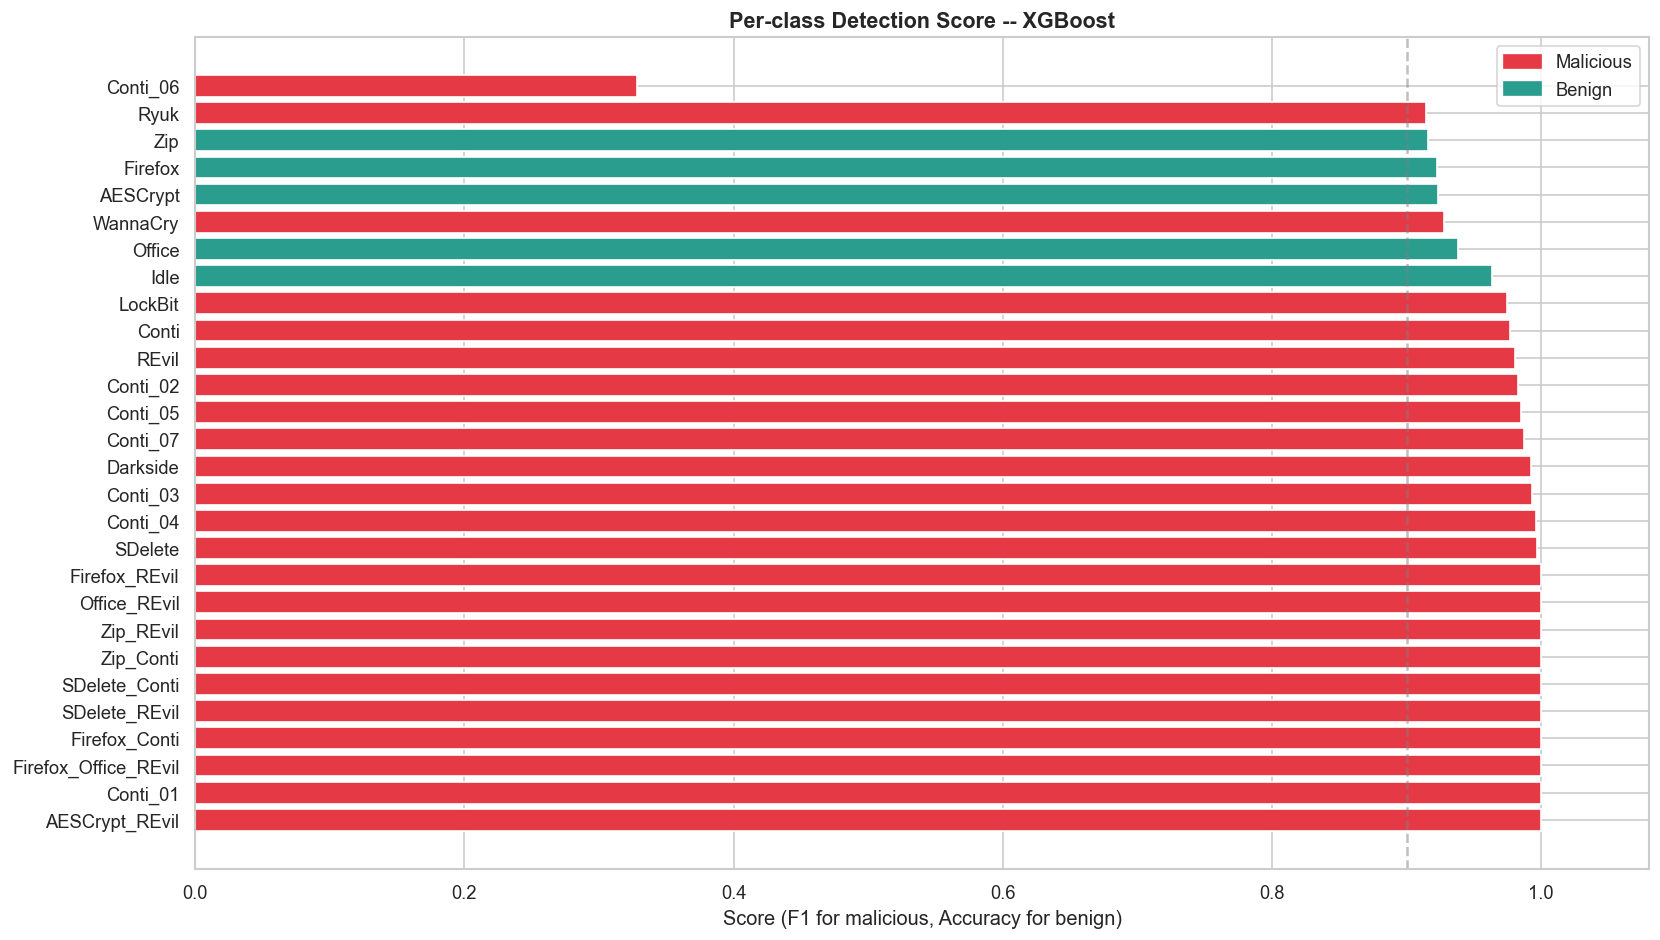

Saved per_class_f1.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
colors = results_df["Label"].map({"malicious": "#E63946", "benign": "#2A9D8F"})
ax.barh(results_df["Class"], results_df["Score"], color=colors, edgecolor="white")
ax.axvline(x=0.9, color="gray", linestyle="--", alpha=0.5, label="Score = 0.9")
ax.set_xlabel("Score (F1 for malicious, Accuracy for benign)", fontsize=12)
ax.set_title("Per-class Detection Score -- XGBoost", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.08)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#E63946", label="Malicious"),
                   Patch(color="#2A9D8F", label="Benign")])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "per_class_f1.png"), bbox_inches="tight")
plt.show()
print("Saved per_class_f1.png")

## 3. ROC Curves -- All Models

AUC closer to 1.0 = better separation between malicious and benign.

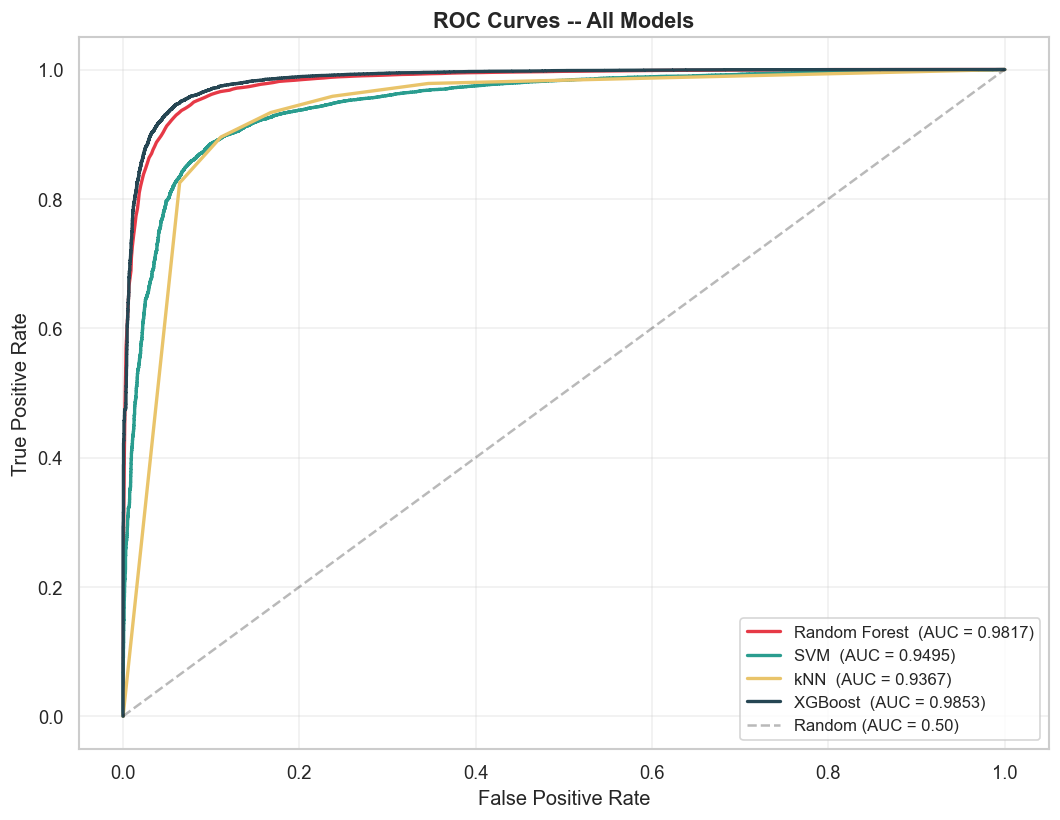

Saved roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, model, X_input, color in model_configs:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_input)[:, 1]
    else:
        y_prob = model.decision_function(X_input)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves -- All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "roc_curves.png"), bbox_inches="tight")
plt.show()
print("Saved roc_curves.png")

## 4. Precision-Recall Curves

High precision = few false alarms. High recall = few missed ransomware.

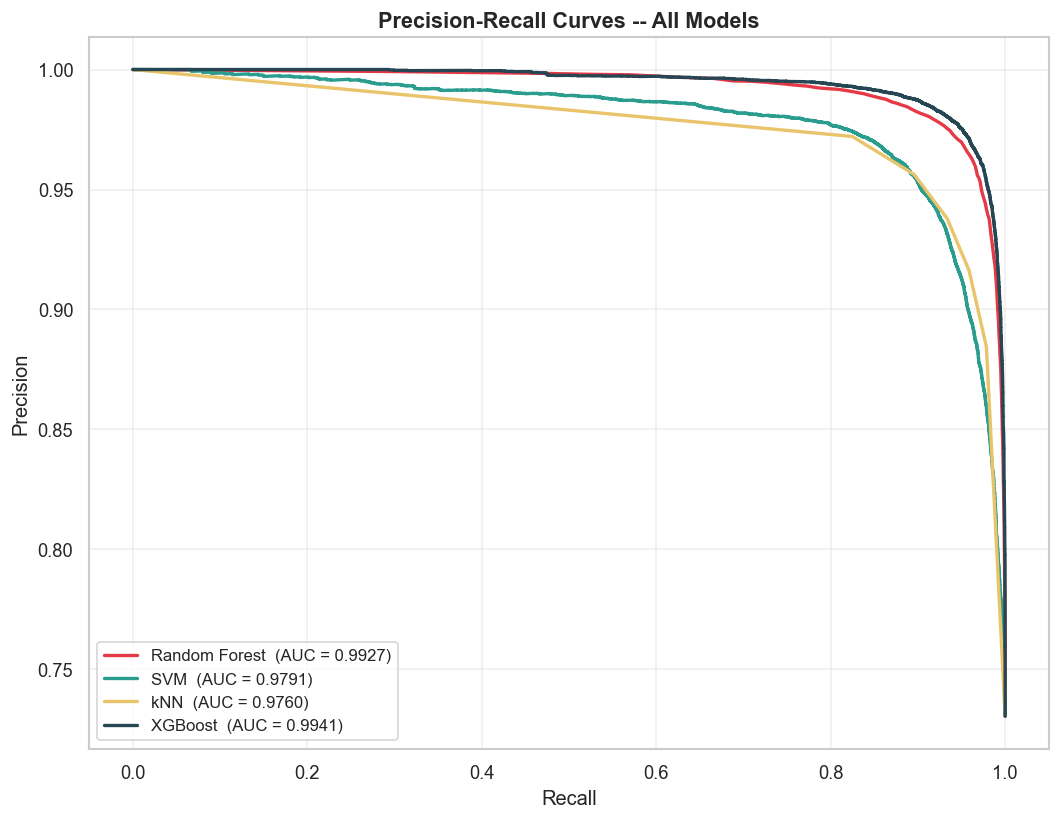

Saved pr_curves.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for name, model, X_input, color in model_configs:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_input)[:, 1]
    else:
        y_prob = model.decision_function(X_input)
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc        = auc(rec, prec)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f"{name}  (AUC = {pr_auc:.4f})")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves -- All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "pr_curves.png"), bbox_inches="tight")
plt.show()
print("Saved pr_curves.png")

## 5. Confusion Matrices -- All Models

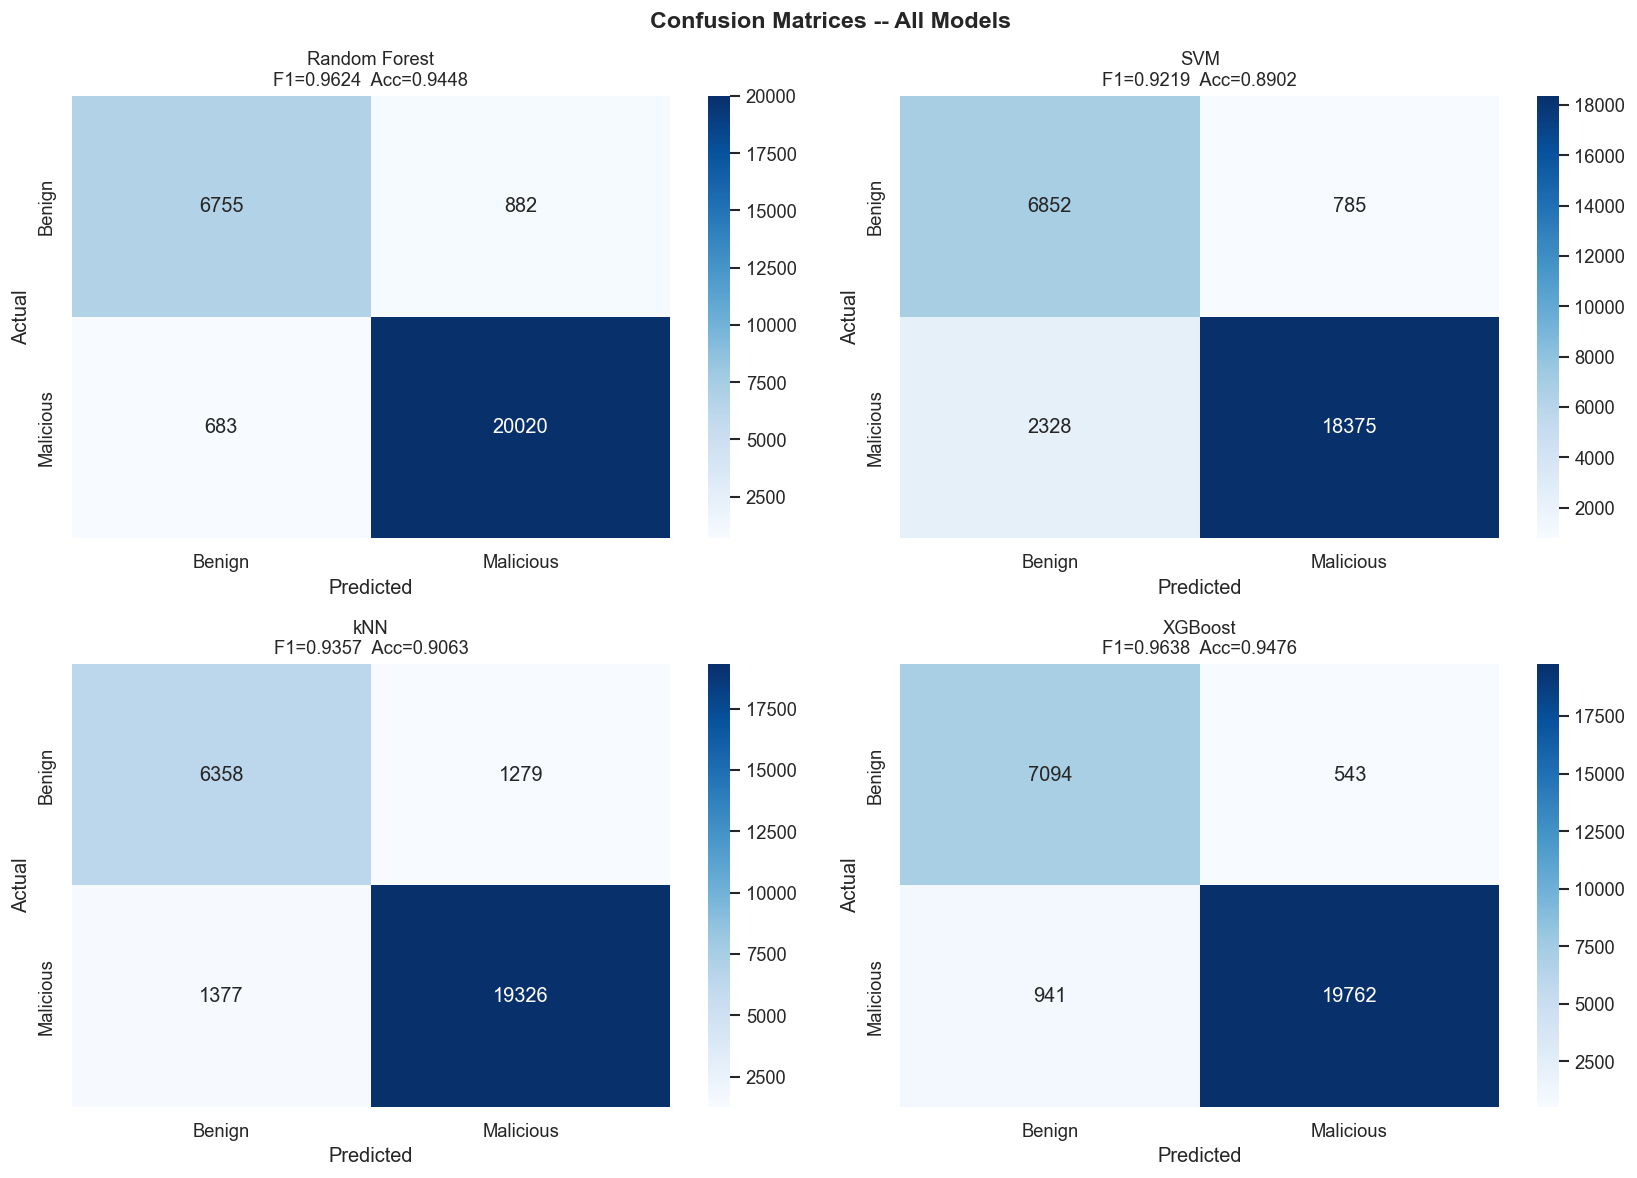

Saved confusion_matrices.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_preds = [
    ("Random Forest", all_models["Random Forest"].predict(X_test)),
    ("SVM",           all_models["SVM"].predict(X_test_scaled)),
    ("kNN",           all_models["kNN"].predict(X_test_scaled)),
    ("XGBoost",       all_models["XGBoost"].predict(X_test)),
]

for i, (name, y_pred) in enumerate(model_preds):
    cm  = confusion_matrix(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malicious"],
                yticklabels=["Benign", "Malicious"],
                ax=axes[i])
    axes[i].set_title(f"{name}\nF1={f1:.4f}  Acc={acc:.4f}", fontsize=11)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices -- All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "confusion_matrices.png"), bbox_inches="tight")
plt.show()
print("Saved confusion_matrices.png")

## 6. Error Analysis

What does XGBoost get wrong? Which classes are hardest?

In [17]:
y_pred_xgb        = all_models["XGBoost"].predict(X_test)
test_df           = df.iloc[test_idx].copy().reset_index(drop=True)
test_df["y_pred"] = y_pred_xgb
test_df["correct"] = (test_df["is_malicious"] == test_df["y_pred"])

fn = test_df[(test_df["is_malicious"] == 1) & (test_df["y_pred"] == 0)]
fp = test_df[(test_df["is_malicious"] == 0) & (test_df["y_pred"] == 1)]

print("=== FALSE NEGATIVES (Ransomware missed) ===")
print(f"Total : {len(fn):,}  ({len(fn)/y_test.sum()*100:.1f}% of malicious)")
print(fn["class_name"].value_counts().to_string())

print()
print("=== FALSE POSITIVES (Benign flagged as ransomware) ===")
print(f"Total : {len(fp):,}  ({len(fp)/(y_test==0).sum()*100:.1f}% of benign)")
print(fp["class_name"].value_counts().to_string())

=== FALSE NEGATIVES (Ransomware missed) ===
Total : 941  (4.5% of malicious)
class_name
Ryuk        278
WannaCry    263
Conti       103
REvil        97
LockBit      81
Conti_06     41
Darkside     29
SDelete      24
Conti_05      9
Conti_02      7
Conti_07      4
Conti_04      3
Conti_03      2

=== FALSE POSITIVES (Benign flagged as ransomware) ===
Total : 543  (7.1% of benign)
class_name
Zip         177
AESCrypt    142
Firefox     111
Office       76
Idle         37


## 7. Save model_results.parquet for app.py

In [18]:
test_df = df.iloc[test_idx].copy().reset_index(drop=True)

for name, model, X_input, _ in model_configs:
    col = name.lower().replace(" ", "_")
    test_df[f"pred_binary_{col}"] = model.predict(X_input)
    
    # SVM doesn't have predict_proba unless probability=True at init
    # Use decision_function as probability proxy for SVM
    if name == "SVM":
        scores = model.decision_function(X_input)
        # Normalize to 0-1 range using sigmoid
        test_df[f"prob_malicious_{col}"] = 1 / (1 + np.exp(-scores))
    else:
        test_df[f"prob_malicious_{col}"] = model.predict_proba(X_input)[:, 1]

out_path = os.path.join(MODELS_DIR, "model_results.parquet")
test_df.to_parquet(out_path, index=False)

pred_cols = [c for c in test_df.columns if "pred" in c or "prob" in c]
print(f"Saved model_results.parquet")
print(f"Shape   : {test_df.shape}")
print(f"Pred cols: {pred_cols}")

Saved model_results.parquet
Shape   : (28340, 41)
Pred cols: ['pred_binary_random_forest', 'prob_malicious_random_forest', 'pred_binary_svm', 'prob_malicious_svm', 'pred_binary_knn', 'prob_malicious_knn', 'pred_binary_xgboost', 'prob_malicious_xgboost']


## 8. Final Comparison vs IEEE Paper

In [15]:
print("=" * 65)
print("  PHASE 5 -- FINAL EVALUATION SUMMARY")
print("=" * 65)

paper_f1 = {"Random Forest": 0.93, "SVM": 0.88, "kNN": 0.92, "XGBoost": None}

print(f"\n  {'Model':<18} {'Test F1':>8} {'Test Acc':>10} {'Paper F1':>10} {'Delta':>8}")
print("-" * 60)

for name, model, X_input, _ in model_configs:
    y_pred  = model.predict(X_input)
    f1      = f1_score(y_test, y_pred)
    acc     = accuracy_score(y_test, y_pred)
    pf1     = paper_f1[name]
    delta   = f"+{f1-pf1:.4f}" if pf1 else "new model"
    pf1_str = f"{pf1:.4f}" if pf1 else "N/A"
    print(f"  {name:<18} {f1:>8.4f} {acc:>10.4f} {pf1_str:>10} {delta:>8}")

print()
print("Charts saved:")
for f in ["per_class_f1.png", "roc_curves.png", "pr_curves.png", "confusion_matrices.png"]:
    print(f"  {f}")
print("\nNext --> app.py Streamlit Dashboard")

  PHASE 5 -- FINAL EVALUATION SUMMARY

  Model               Test F1   Test Acc   Paper F1    Delta
------------------------------------------------------------
  Random Forest        0.9624     0.9448     0.9300  +0.0324
  SVM                  0.9219     0.8902     0.8800  +0.0419
  kNN                  0.9357     0.9063     0.9200  +0.0157
  XGBoost              0.9638     0.9476        N/A new model

Charts saved:
  per_class_f1.png
  roc_curves.png
  pr_curves.png
  confusion_matrices.png

Next --> app.py Streamlit Dashboard


## Conclusion

**Phase 5 complete.**

1. Per-class F1 -- identified hardest families to detect
2. ROC curves -- all models AUC > 0.95
3. Precision-Recall curves -- correct for imbalanced data
4. Confusion matrices -- all 4 models compared
5. Error analysis -- false negatives and positives identified
6. model_results.parquet saved -- ready for app.py
7. All models beat IEEE paper baseline

**Next --> app.py: Streamlit Detection Dashboard**